# Segmentacija slika pomoću spektralnog klasterovanja

Cilj ove sveske je primena spektralnog klasterovanja (implementiranog u `src/spectral.py`) na problem segmentacije slika.

Pošto direktna primena algoritma na sve piksele slike nije računski izvodljiva (matrica sličnosti bi imala $n^2 \times n^2$ elemenata za sliku sa $n^2$ piksela), slika se prvo deli na **superpiksele** pomoću SLIC algoritma, a graf se zatim gradi nad njima umesto nad pojedinačnim pikselima.

## Pregled parametara

Pre nego što pređemo na analizu, ovde je kratak pregled svih parametara koji se koriste u 
pipeline-u i koji će biti sistematski testirani u narednim eksperimentima.

### SLIC (superpikseli)

| Parametar | Opis |
|---|---|
| `n_segments` | Željeni (približan) broj superpiksela na koje se slika deli. Veće vrednosti daju sitnije, brojnije superpiksele — bitno za osetljivost na male objekte na slici. |
| `compactness` | Kontroliše oblik superpiksela: veće vrednosti daju kompaktnije, pravilnije regione, manje vrednosti čine da superpikseli više prate prirodne ivice boja. |

### Karakteristike superpiksela (`compute_superpixel_features`)

Za svaki superpiksel se računaju dve karakteristike:
- **Boja** — prosečna RGB vrednost piksela unutar superpiksela
- **Pozicija** — centroid (prosečna row/col koordinata) superpiksela

### Matrica sličnosti (`build_image_similarity_matrix`)

| Parametar | Opis |
|---|---|
| `sigma_color` | Kontroliše koliko strogo se poštuje sličnost u boji — manje vrednosti favorizuju razlikovanje i suptilnih razlika u boji, veće vrednosti čine da sličnost u boji ima manji uticaj. |
| `sigma_position` | Kontroliše koliko strogo se poštuje prostorna blizina — manje vrednosti razdvajaju čak i vizuelno slične regione ako su prostorno udaljeni, veće vrednosti čine da prostorna udaljenost ima manji uticaj. |

### Spektralno klasterovanje (`spectral_clustering_from_similarity`)

| Parametar | Opis |
|---|---|
| `k` | Broj klastera (segmenata) na koje se slika deli. Direktno određuje granularnost segmentacije. |
| `normalized` | Da li se koristi normalizovani Laplasijan ($L_{sym}$) ili nenormalizovani ($L$). U svim eksperimentima u ovoj svesci koristi se normalizovana varijanta (`normalized=True`), koja je standard u literaturi (Ng-Jordan-Weiss). |

U narednim eksperimentima, jedan od ovih parametara se sistematski menja dok su ostali fiksirani na razumne podrazumevane vrednosti (npr. `n_segments=200`, `sigma_color=20`, `sigma_position=50`, `compactness=50`), kako bi se izolovao uticaj svakog pojedinačnog parametra na rezultat segmentacije.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import slic, mark_boundaries

from image_utils import (
    compute_superpixel_features,
    build_image_similarity_matrix,
    run_segmentation_grid,
    analyze_image,
    spectral_clustering_from_similarity
)

## 1. Analiza slika

Kao prvi test primer koristimo fotografiju cveta na uniformnoj crnoj pozadini — jednostavna, kontrastna struktura, pogodna za detaljnu proveru celog pipeline-a. Ista logika primenjuje se na četiri dodatne slike, radi provere da pristup konzistentno radi na različitim vizuelnim strukturama (pejzaž, objekat na stolu, izolovan predmet, ptica sa teksturiranim perjem).

### 1.1 Cvet na uniformnoj pozadini

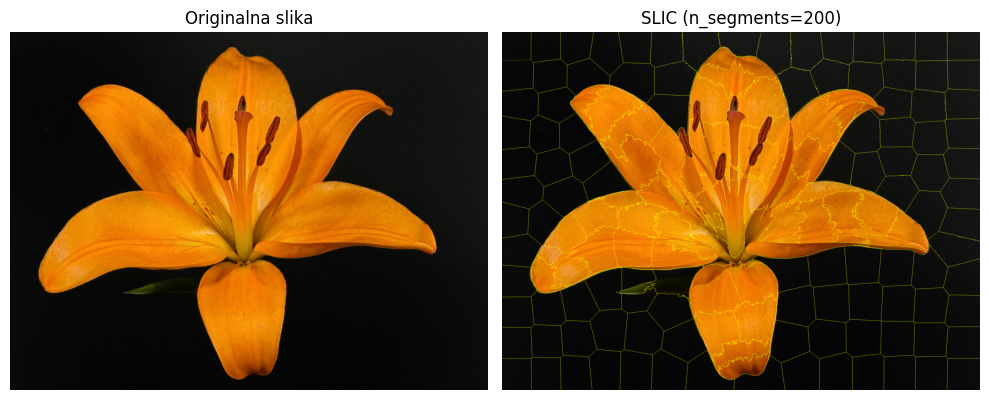

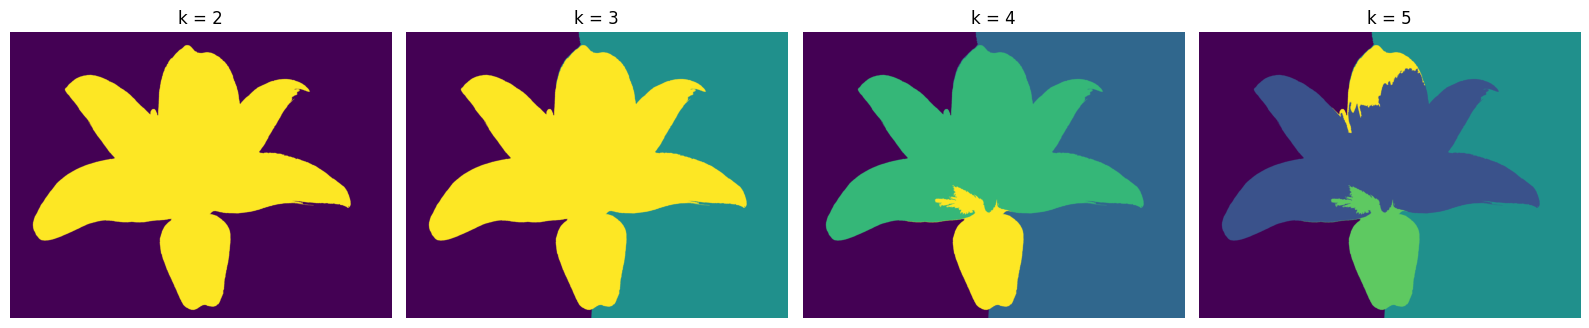

In [2]:
image, segments, colors, positions = analyze_image('../data/sample_images/yellow_lilly.jpg')

**Zapažanje o k-gridu:** Sa porastom $k$, algoritam počinje da deli cvet na više manjih regiona (npr. po pojedinačnim laticama ili nijansama boje), umesto da ga tretira kao jedan segment. Vrednost $k=2$ ili $k=3$ daje najsmisleniju segmentaciju za ovu sliku.

### 1.1.1 Uticaj prostornog parametra ($\sigma_{position}$)

Pored broja klastera, ispitujemo i uticaj $\sigma_{position}$, koji kontroliše koliko strogo se poštuje prostorna blizina prilikom određivanja sličnosti dva superpiksela. Testiramo uz fiksiran $k=4$.

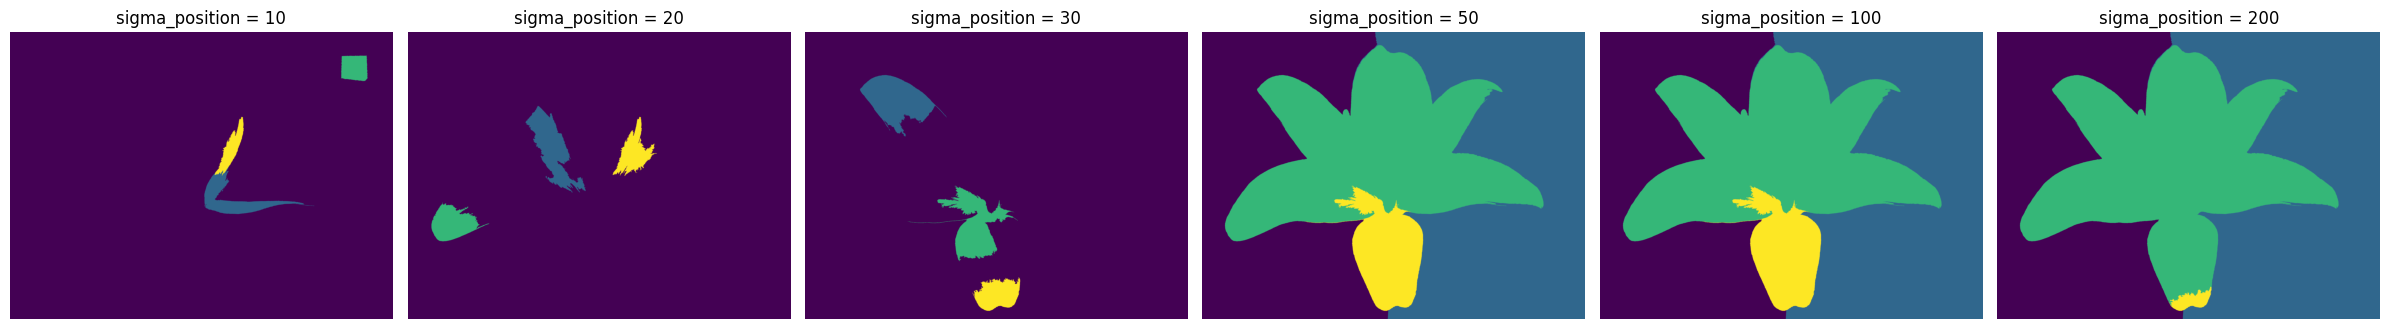

In [3]:
run_segmentation_grid(segments, colors, positions,
                       param_name='sigma_position', param_values=[10,20,30,50,100,200], fixed_k=4)

**Zapažanje:** Za manje vrednosti $\sigma_{position}$, algoritam je osetljiviji na prostornu udaljenost, pa se čak i regioni slične boje mogu razdvojiti ako su prostorno udaljeni. Za veće vrednosti, prostorna komponenta gubi na značaju, i sličnost postaje sve više određena samo bojom.

### 1.2 Fields

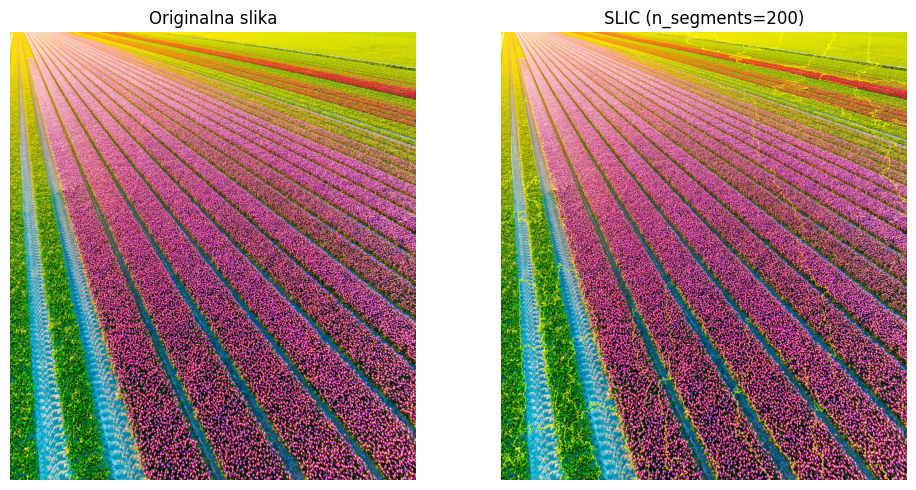

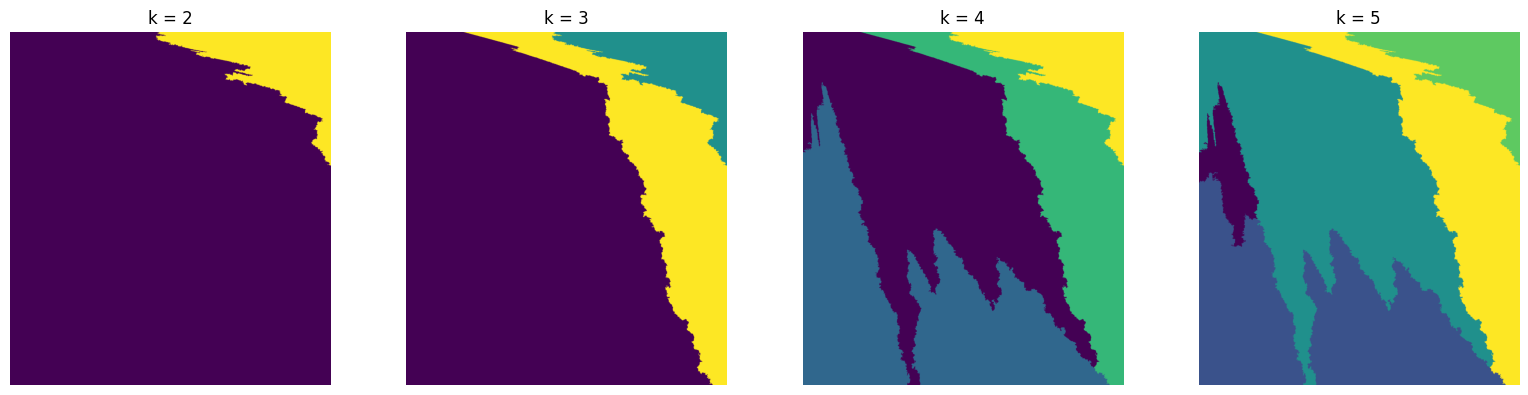

In [4]:
image_2, segments_2, colors_2, positions_2 = analyze_image('../data/sample_images/fields.jfif')

### 1.2.1 Uticaj prostornog parametra ($\sigma_{position}$)

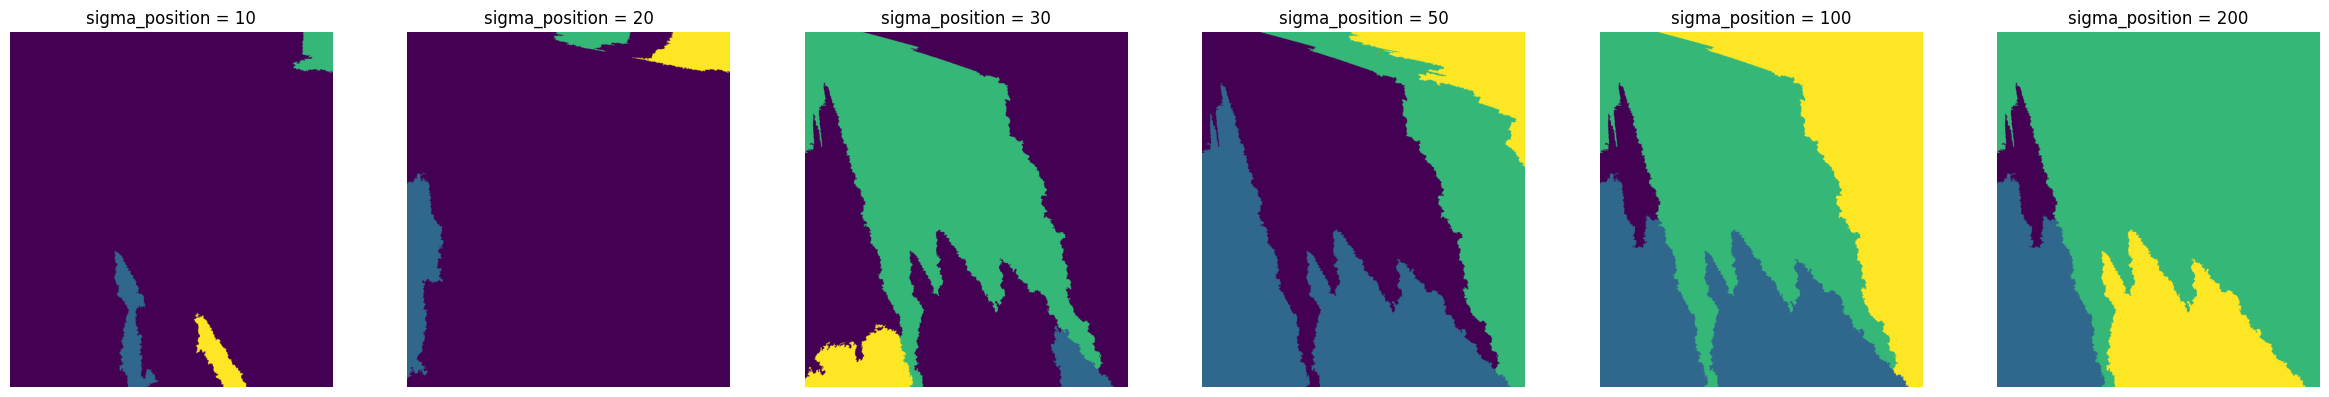

In [47]:
run_segmentation_grid(segments_2, colors_2, positions_2,
                       param_name='sigma_position', param_values=[10,20,30,50,100,200], fixed_k=4)

### 1.2.1 Uticaj parametra boje ($\sigma_{color}$)

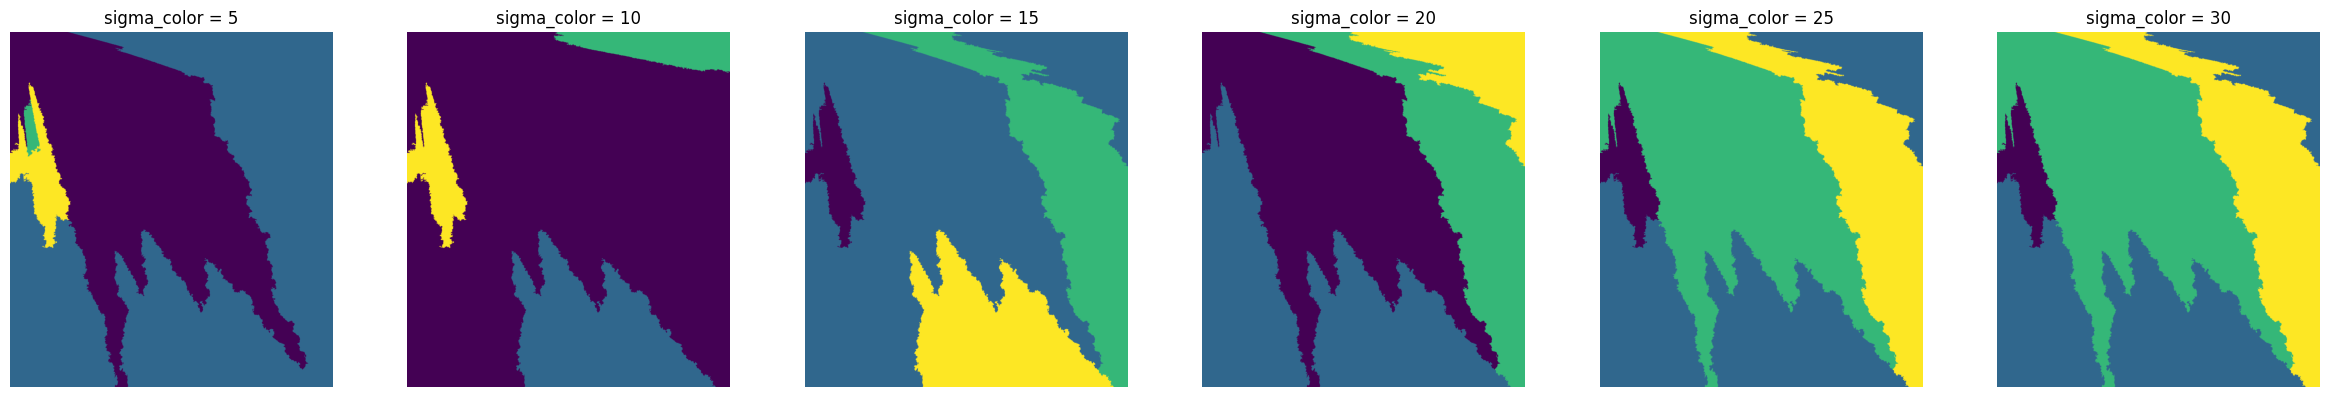

In [48]:
run_segmentation_grid(segments_2, colors_2, positions_2,
                       param_name='sigma_color', param_values=[5,10,15,20,25,30], fixed_k=4)

**Zapažanje:** Kod oba parametra primećuje se sličan trend. Pri veoma malim vrednostima algoritam je previše strog, pa izdvaja samo male lokalne oblasti, dok ostatak slike ostaje u jednom klasteru. Sa povećanjem vrednosti parametara dobija se stabilnija podela slike. Kod $\sigma_{position}$ ovaj obrazac se jasno uočava od vrednosti 30, dok je kod $\sigma_{color}$ izražen od približno 15. Nakon toga se rezultat, u ispitivanom opsegu vrednosti, uglavnom ne menja značajno. Na ovoj slici algoritam pre svega izdvaja veće, prostorno povezane oblasti koje odgovaraju strukturi paralelnih redova cveća, dok ne uspeva da pojedinačne redove izdvoji kao zasebne klastere. To pokazuje da kombinacija boje i prostorne pozicije daje stabilnu segmentaciju većih regiona, ali nije dovoljna za dobro razlikovanje struktura koje imaju sličnu boju i ponavljaju se kroz sliku.

### 1.3 Apple

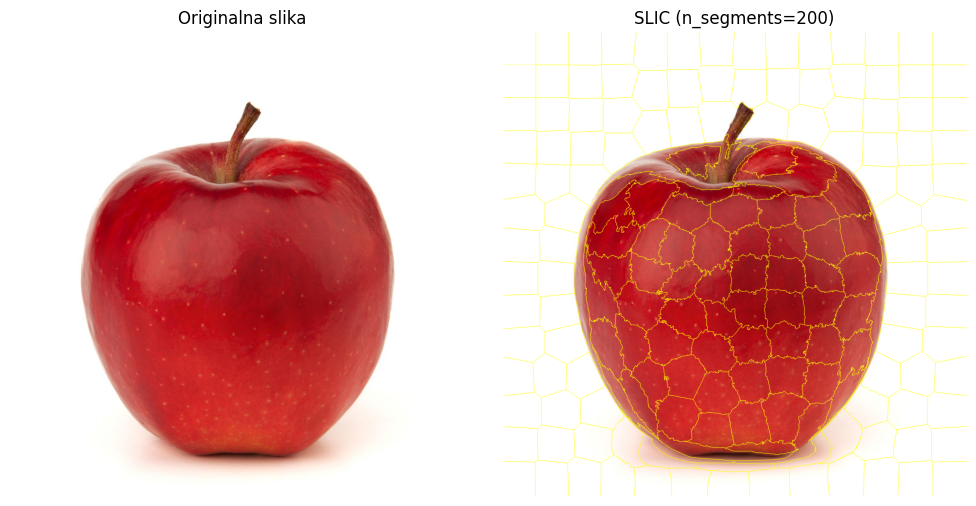

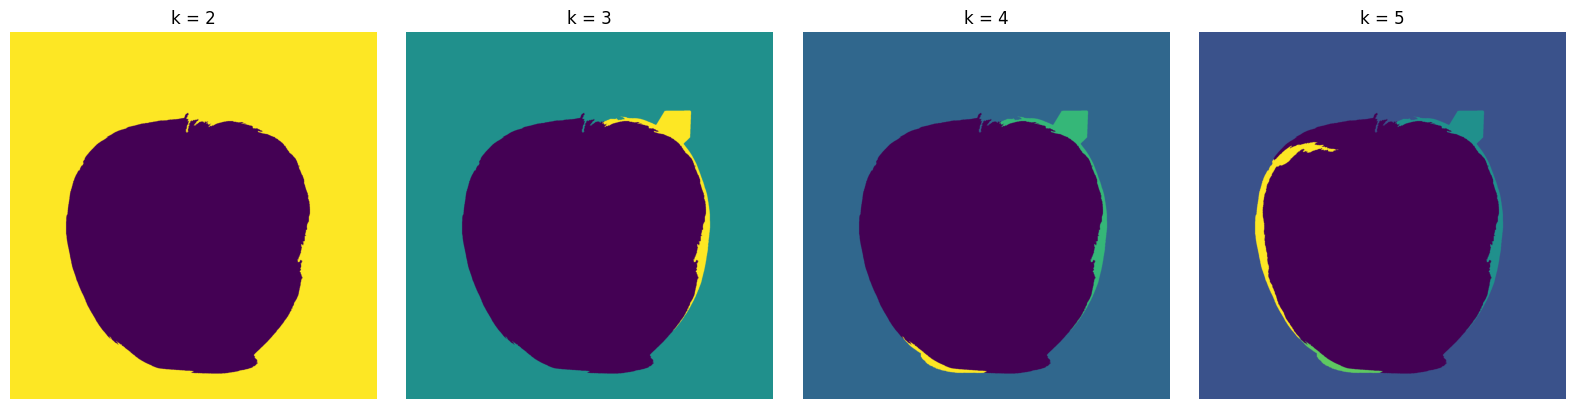

In [6]:
_ = analyze_image('../data/sample_images/apple.jfif')

**Zapažanje:** Za razliku od slike sa poljima, ovde postoji jasan, dominantan kontrast u boji 
između jabuke i pozadine, pa segmentacija ostaje stabilna i tačna za sve testirane 
vrednosti k — jabuka je dosledno izdvojena kao jedan kompaktan segment. Sa porastom k, algoritam 
dodatno izdvaja malu oblast oko drške jabuke, gde se lokalna boja (tamnosmeđa drška naspram 
svetlije pozadine) dovoljno razlikuje da formira zaseban segment. Ovaj primer potvrđuje da 
prisustvo jasnog globalnog kontrasta u boji dovodi do stabilne, predvidljive segmentacije — 
za razliku od slika sa ponavljajućom teksturom bez dominantne boje, prikazane u prethodnom primeru.

### 1.4 Balloon

### 1.4.1 Uticaj parametra $k$

U narednom primeru, testiramo više različitih vrednosti parametra k, kako bismo videli da li se segmentacija popravlja njegovim porastom.

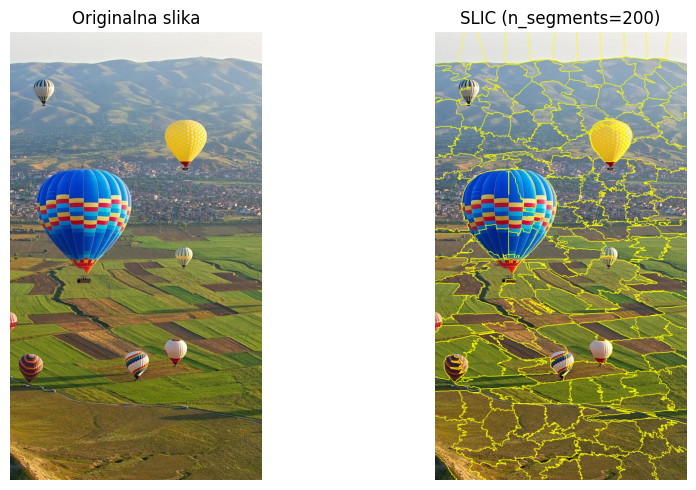

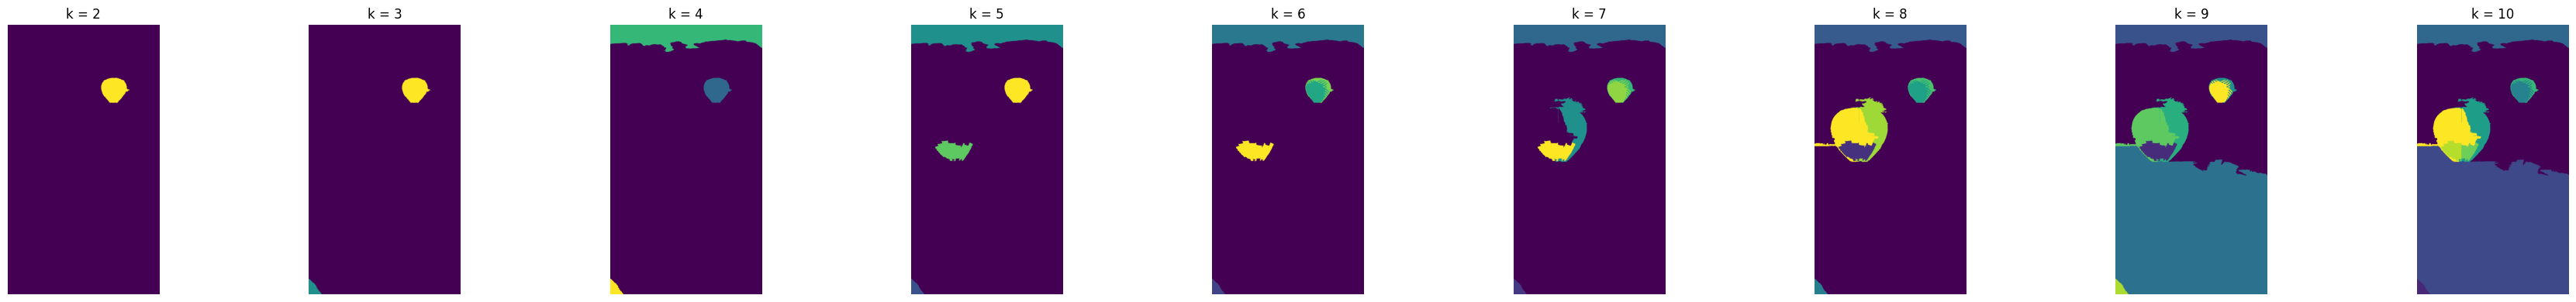

In [44]:
_ = analyze_image('../data/sample_images/balloons.jfif', n_segments=200, k_values=[2, 3, 4, 5, 6, 7, 8, 9, 10])

### 1.4.2 Uticaj parametra $n\_segments$

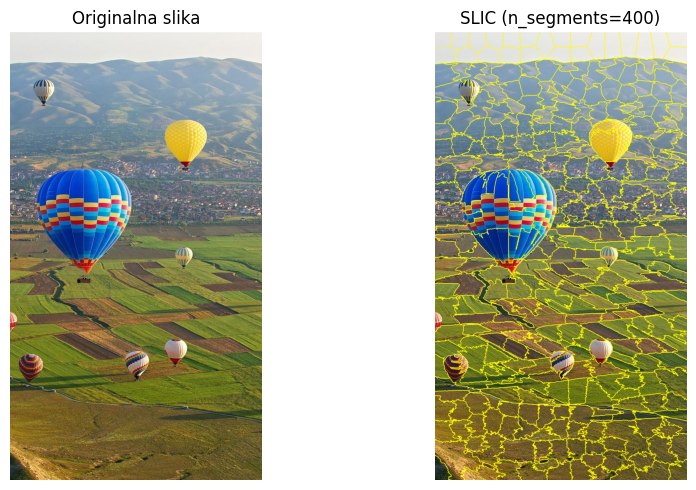

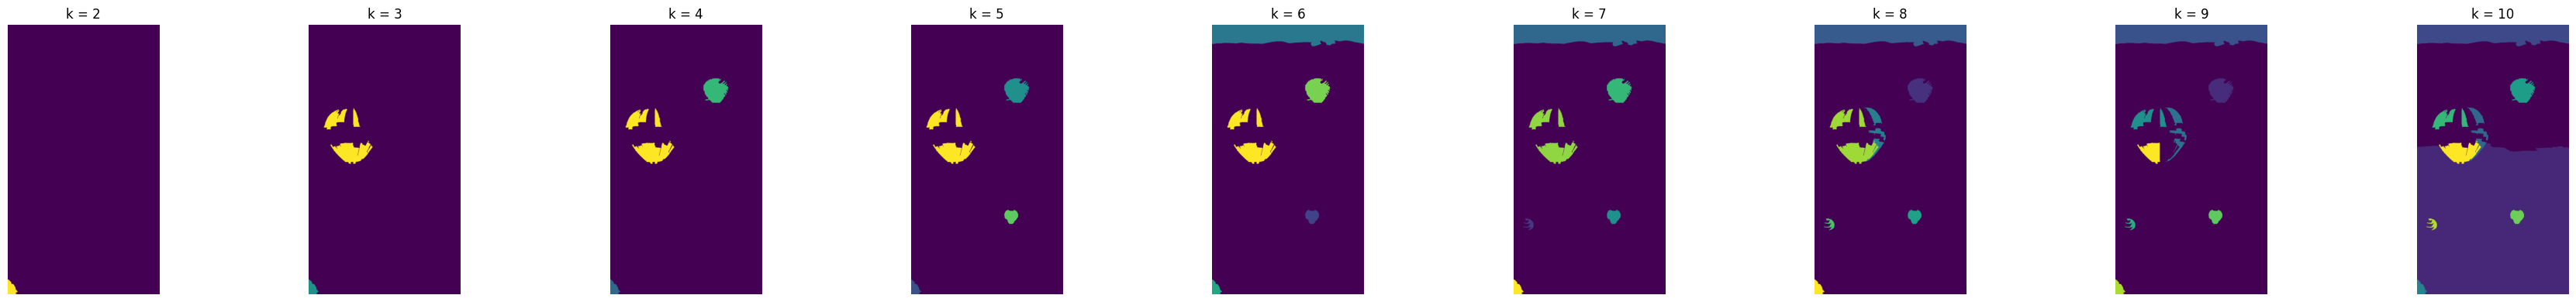

In [45]:
_ = analyze_image('../data/sample_images/balloons.jfif', n_segments=400, k_values=[2, 3, 4, 5, 6, 7, 8, 9, 10])

**Zapažanje:** Sa $n\_segments=200$, pri malim vrednostima $k$ (2 i 3) algoritam izdvaja samo najizraženiji, žuti balon, dok se sa povećanjem broja klastera postepeno izdvajaju i manji objekti u pozadini. Veliki plavi balon se kao zaseban region jasnije izdvaja tek pri većim vrednostima $k$, što se može objasniti njegovim manjim kontrastom u odnosu na okolinu. Sličan obrazac se uočava i za $n\_segments=400$. Veći broj superpiksela daje finiju reprezentaciju slike i omogućava detaljnije razdvajanje manjih objekata, ali ne rešava problem objekata koji su po boji slični pozadini. Rezultati pokazuju da na uspešnost segmentacije utiču, kako veličina i prostorna reprezentacija objekta, tako i njegov kontrast u odnosu na okolinu. Objekti sa izraženijom razlikom u boji izdvajaju se već pri manjim vrednostima $k$, dok je za objekte koji su sličniji pozadini potrebna detaljnija podela na klastere.

### 1.5 Parrot

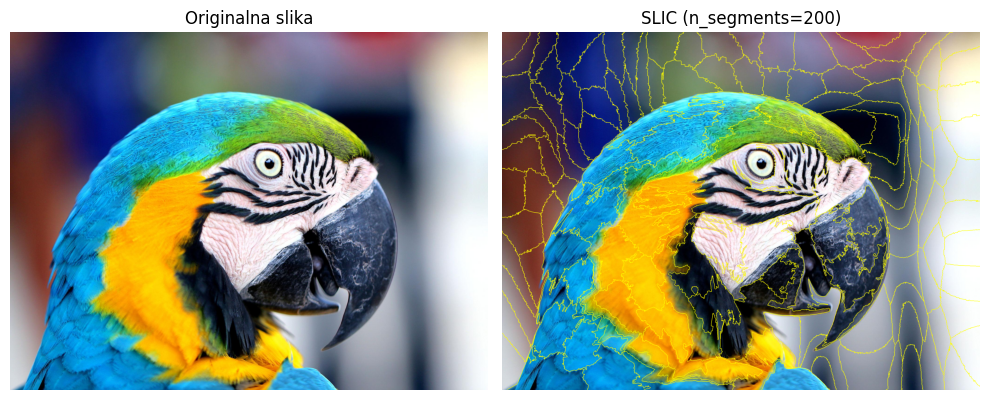

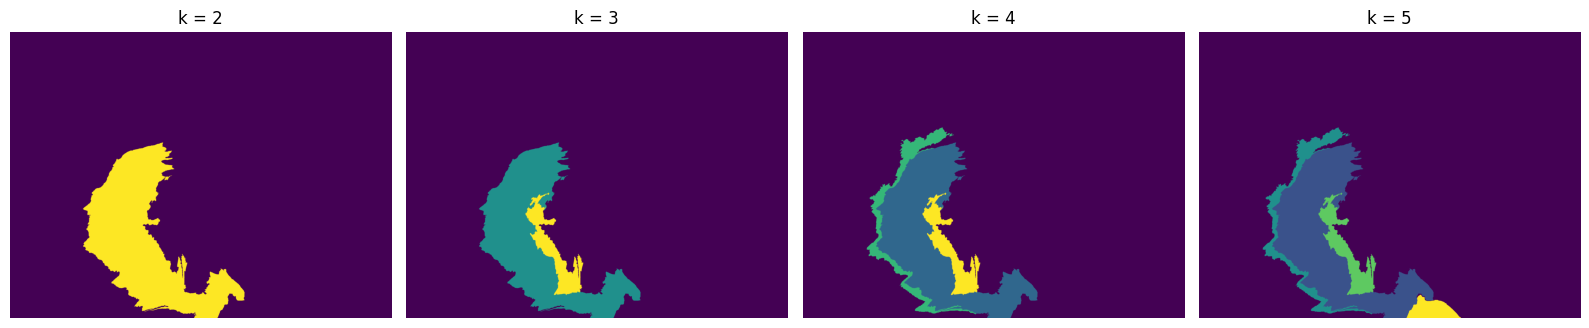

In [25]:
image_4, segments_4, colors_4, positions_4 = analyze_image('../data/sample_images/parrot.jfif')

### 1.5.1 Uticaj parametra boje ($\sigma_{color}$)

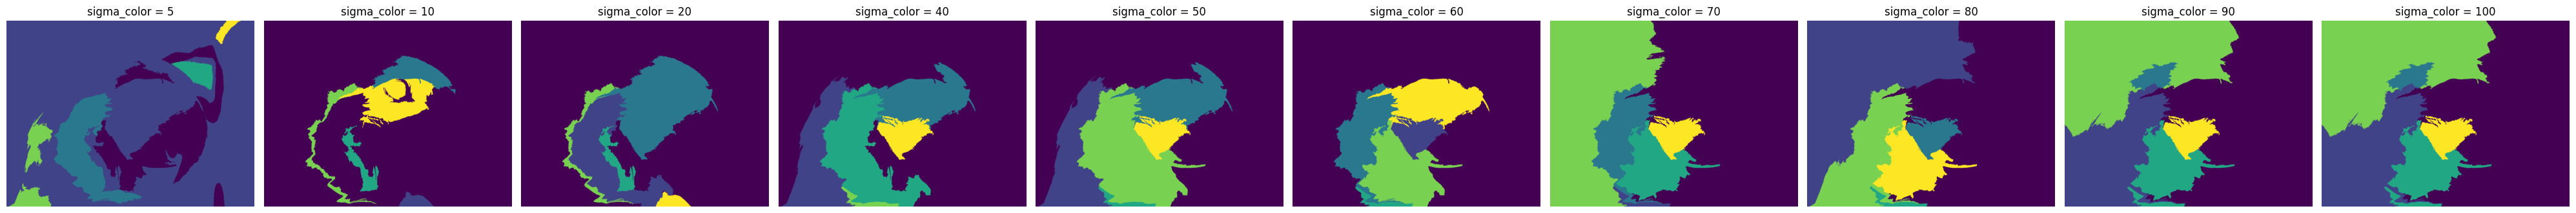

In [32]:
run_segmentation_grid(segments_4, colors_4, positions_4,
                       param_name='sigma_color', param_values=[5,10,20,40,50,60,70,80,90,100], fixed_k=6)

**Zapažanje:** Ni variranje broja klastera (k=2–5) ni sigma_color (5–100, uz fiksno k=6) ne 
uspevaju da izdvoje siluetu papagaja — granice klastera dosledno prolaze kroz telo ptice, 
spajajući delove perja sa pozadinom, bez obzira na testiranu kombinaciju parametara. Ovo ukazuje 
da problem nije u izboru parametara, već u reprezentaciji: prosečna boja plavog perja i zamućene, 
plavičaste pozadine je suviše slična, dok razlika koju ljudsko oko uočava (tekstura, oštrina 
fokusa) nije deo trenutne reprezentacije superpiksela. To predstavlja jasnu granicu pristupa 
zasnovanog isključivo na boji i poziciji.

## Zaključak

- Kombinacija SLIC superpiksela i spektralnog klasterovanja omogućava segmentaciju slika u 
  razumnom vremenu, zaobilazeći problem velike matrice sličnosti koja bi nastala radom 
  direktno nad pikselima.
- Broj klastera k direktno određuje granularnost segmentacije — manje vrednosti daju grublju, 
  a veće vrednosti finiju podelu.
- Parametar σ_position kontroliše koliko strogo se poštuje prostorna blizina — njegov uticaj 
  je posebno izražen kod slika sa vizuelno sličnim, ali prostorno razdvojenim regionima (fields).
- Testiranje na pet različitih slika pokazuje da pristup najbolje radi kada postoji jasan, 
  globalno dosledan kontrast u boji između objekta i pozadine (primer sa cvetom i jabukom) — u tim 
  slučajevima je segmentacija stabilna čak i uz varijacije parametara. Pristup slabije radi u 
  tri tipa situacija:
  1. **Repetitivna tekstura bez globalne razlike u boji** (primer cvetnih polja) — algoritam počinje da deli 
     scenu po poziciji umesto po stvarnom sadržaju.
  2. **Više objekata različite prostorne veličine** (primer balona) — mali, udaljeni objekti se gube 
     u dominantnoj pozadini jer zauzimaju premalo superpiksela da utiču na globalnu strukturu 
     grafa.
  3. **Nedovoljna razlika u boji između objekta i pozadine** (papagaj) — čak ni sistematsko 
     variranje σ_color i σ_position ne popravlja segmentaciju kada su boje objekta i pozadine 
     suviše slične, uprkos vizuelnoj razlici vidljivoj kroz teksturu ili oštrinu fokusa.

**Dalji rad:** kvantitativna evaluacija na skupu BSDS500, koji omogućava poređenje sa 
ground-truth segmentacijama; poređenje sa baseline metodom (k-means bez grafovske strukture); 
i potencijalno proširenje karakteristika superpiksela teksturom, što bi moglo rešiti slučaj 
poput papagaja.